# Phase 4a — Cross-Device Generalization (Leave-One-Device-Out)
**Project:** Robust Respiratory Sound Classification under Noise and Domain Shift using Audio Spectrogram Transformers

**Goal:** measure how much performance falls when the model has never seen a given recording device during training. ICBHI 2017 was collected with 4 different devices (AKGC417L, LittC2SE, Litt3200, Meditron) -- your Phase 3 model saw all 4 mixed together. This notebook asks the harder question: train on 3, test on the 4th, entirely held out, repeated for each device.

**Training recipe:** identical to your Phase 3 winner (Focal Loss + SpecAugment + Mixup, gamma=2.0, alpha=0.4) -- the only variable being changed here is *which devices are in the training pool*, so any score drop is attributable to the device shift itself, not a different model.

**Required inputs for this notebook (Add Input on Kaggle):**
1. `03a-ast-finetuning-ce` -- for cached raw waveforms
2. `01-data-preparation` -- for the full cycle-level data (train/val/test CSVs, recombined here into one pool)

**Compute note:** 4 full training runs, one per held-out device. Comment out devices in `DEVICES_TO_RUN` if you want to split this across sessions.

In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, sosfiltfilt
import librosa

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

from transformers import ASTFeatureExtractor, ASTForAudioClassification, get_linear_schedule_with_warmup

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

plt.rcParams["figure.dpi"] = 110

## **1. Config**

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

PHASE1_DIR = Path(
    "/kaggle/input/notebooks/praveshsubba/01-data-preparation/icbhi_processed"
)
SPLIT_DIR = PHASE1_DIR / "splits"

CE_NOTEBOOK_DIR = Path(
    "/kaggle/input/notebooks/praveshsubba/03a-ast-finetuning-ce"
)
WAVEFORM_CACHE_DIR = CE_NOTEBOOK_DIR / "waveform_cache"

CHECKPOINT_DIR = Path("/kaggle/working/checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_CSV = Path("/kaggle/working/results_phase4a.csv")

LABELS = ["normal", "crackle", "wheeze", "both"]

TARGET_SR = 16000
LOWCUT = 50
HIGHCUT = 8000
TARGET_DURATION = 8.0

AST_CHECKPOINT = "MIT/ast-finetuned-audioset-10-10-0.4593"

BATCH_SIZE = 8
NUM_WORKERS = 2
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
MAX_EPOCHS = 15
EARLY_STOP_PATIENCE = 4
GRAD_CLIP_NORM = 1.0

FOCAL_GAMMA = 2.0
TIME_MASK_PARAM = 100
FREQ_MASK_PARAM = 20
N_TIME_MASKS = 2
N_FREQ_MASKS = 2
MIXUP_ALPHA = 0.4

VAL_FRAC_WITHIN_POOL = 0.15   # patient-level val carved out of each fold's training pool

# which held-out devices to run this session -- edit as needed
DEVICES_TO_RUN = ["AKGC417L", "LittC2SE", "Litt3200", "Meditron"]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
assert DEVICE.type == "cuda" # "Enable the GPU accelerator for this notebook before continuing.

Device: cuda


## **2. Recombine the full cycle pool**

Phase 1's train/val/test CSVs are patient-level splits mixing all devices together -- for this experiment we need a different split axis entirely (by device, not by patient), so the three files are recombined into one pool first.

In [3]:
train_df = pd.read_csv(SPLIT_DIR / "train.csv")
val_df   = pd.read_csv(SPLIT_DIR / "val.csv")
test_df  = pd.read_csv(SPLIT_DIR / "test.csv")

required_cols = {
    "audio_path", "start", "end",
    "label", "patient_id", "equipment"
}

missing = required_cols - set(train_df.columns)
assert not missing, f"Missing expected columns: {missing}"

from pathlib import Path

def resolve_waveform_path(row, cache_dir=WAVEFORM_CACHE_DIR):
    cycle_id = (
        f"{Path(row['audio_path']).stem}_"
        f"{float(row['start'])}_"
        f"{float(row['end'])}"
    )

    waveform_path = cache_dir / f"{cycle_id}.npy"

    if not waveform_path.exists():
        raise FileNotFoundError(
            f"Waveform not found:\n{waveform_path}"
        )

    return str(waveform_path)


# Create waveform_path BEFORE concatenating
for name, df in [
    ("train", train_df),
    ("val", val_df),
    ("test", test_df)
]:
    df["waveform_path"] = [
        resolve_waveform_path(row)
        for _, row in df.iterrows()
    ]

    print(f"{name}: {len(df)} waveform paths created")


# NOW combine them
full_df = pd.concat(
    [train_df, val_df, test_df],
    ignore_index=True
)

print("\nAll waveform paths resolved successfully.")
print(full_df.columns.tolist())

train: 4580 waveform paths created
val: 1133 waveform paths created
test: 1185 waveform paths created

All waveform paths resolved successfully.
['cycle_id', 'patient_id', 'recording_id', 'chest_location', 'acquisition_mode', 'equipment', 'audio_path', 'start', 'end', 'crackle', 'wheeze', 'label', 'duration', 'spectrogram_path', 'waveform_path']


## **4. Per-device fold splitting**

For a held-out device `D`: everything recorded on `D` becomes the test set, untouched during training. Everything else is split patient-level into train/val (same leakage-safe logic as Phase 1) -- a patient never appears in both the training pool and the held-out device's test set, since they're partitioned by device first.

In [4]:
def make_device_fold(full_df, held_out_device, val_frac=VAL_FRAC_WITHIN_POOL, seed=SEED):
    test_fold = full_df[full_df["equipment"] == held_out_device].reset_index(drop=True)
    pool = full_df[full_df["equipment"] != held_out_device].reset_index(drop=True)

    rng = np.random.default_rng(seed)
    patients = np.array(pool["patient_id"].unique(), dtype=object)
    rng.shuffle(patients)
    n_val = int(round(len(patients) * val_frac))
    val_patients = set(patients[:n_val])

    val_fold = pool[pool["patient_id"].isin(val_patients)].reset_index(drop=True)
    train_fold = pool[~pool["patient_id"].isin(val_patients)].reset_index(drop=True)

    # leakage check: no patient in both train_fold and val_fold
    overlap = set(train_fold["patient_id"]) & set(val_fold["patient_id"])
    assert not overlap, f"Patient leakage between train/val fold: {overlap}"

    return train_fold, val_fold, test_fold

## **5. SpecAugment, Mixup, FocalLoss, ICBHI Score**

In [5]:
def spec_augment(x, time_mask_param=TIME_MASK_PARAM, freq_mask_param=FREQ_MASK_PARAM,n_time_masks=N_TIME_MASKS, n_freq_masks=N_FREQ_MASKS):
    x = x.clone()
    T, M = x.shape
    fill_value = x.mean()
    for _ in range(n_time_masks):
        t = np.random.randint(0, time_mask_param)
        t0 = np.random.randint(0, max(T - t, 1))
        x[t0:t0 + t, :] = fill_value
    for _ in range(n_freq_masks):
        f = np.random.randint(0, freq_mask_param)
        f0 = np.random.randint(0, max(M - f, 1))
        x[:, f0:f0 + f] = fill_value
    return x

def mixup_batch(x, y, alpha=MIXUP_ALPHA):
    batch_size = x.size(0)
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    perm = torch.randperm(batch_size, device=x.device)
    x_mixed = lam * x + (1 - lam) * x[perm]
    return x_mixed, y, y[perm], lam


class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha, self.gamma, self.reduction = alpha, gamma, reduction

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction="none")
        p_t = torch.exp(-ce_loss)
        loss = (1 - p_t) ** self.gamma * ce_loss
        if self.alpha is not None:
            loss = self.alpha[targets] * loss
        return loss.mean() if self.reduction == "mean" else (loss.sum() if self.reduction == "sum" else loss)


def icbhi_score(y_true_labels, y_pred_labels):
    y_true_abn = np.array([l != "normal" for l in y_true_labels])
    y_pred_abn = np.array([l != "normal" for l in y_pred_labels])
    normal_mask = ~y_true_abn
    specificity = (~y_pred_abn[normal_mask]).sum() / max(normal_mask.sum(), 1)
    abnormal_mask = y_true_abn
    sensitivity = y_pred_abn[abnormal_mask].sum() / max(abnormal_mask.sum(), 1)
    return {"sensitivity": sensitivity, "specificity": specificity, "icbhi_score": (sensitivity + specificity) / 2}


idx2label = {i: l for i, l in enumerate(LABELS)}

def evaluate_and_report(y_true, y_pred, model_name):
    scores = icbhi_score(y_true, y_pred)
    print(f"--- {model_name} ---")
    print(f"Sensitivity: {scores['sensitivity']*100:.2f}%  Specificity: {scores['specificity']*100:.2f}%  "
          f"ICBHI Score: {scores['icbhi_score']*100:.2f}%")
    print(classification_report(y_true, y_pred, labels=LABELS, zero_division=0))
    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    disp = ConfusionMatrixDisplay(cm, display_labels=LABELS)
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(model_name)
    plt.tight_layout()
    plt.show()
    return scores


results_log = []

def log_result(model_name, split, scores, notes=""):
    results_log.append({
        "model": model_name, "split": split,
        "sensitivity": scores["sensitivity"], "specificity": scores["specificity"],
        "icbhi_score": scores["icbhi_score"], "notes": notes,
    })
    pd.DataFrame(results_log).to_csv(RESULTS_CSV, index=False)

## **6. Dataset + training routine (Focal + SpecAugment + Mixup, reused unchanged)**

In [6]:
feature_extractor = ASTFeatureExtractor.from_pretrained(AST_CHECKPOINT)

class ASTLungSoundDataset(Dataset):
    def __init__(self, df, feature_extractor, label_list=LABELS, use_specaugment=False):
        self.df = df.reset_index(drop=True)
        self.fe = feature_extractor
        self.label2idx = {l: i for i, l in enumerate(label_list)}
        self.use_specaugment = use_specaugment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        waveform = np.load(row["waveform_path"])
        x = self.fe(waveform, sampling_rate=TARGET_SR, return_tensors="pt")["input_values"].squeeze(0)
        if self.use_specaugment:
            x = spec_augment(x)
        y = torch.tensor(self.label2idx[row["label"]], dtype=torch.long)
        return x, y


def train_one_fold(held_out_device, train_fold, val_fold, test_fold):
    print(f"\n{'='*60}\nHeld-out device: {held_out_device}  "
          f"(train={len(train_fold)}, val={len(val_fold)}, test={len(test_fold)})\n{'='*60}")

    train_ds = ASTLungSoundDataset(train_fold, feature_extractor, use_specaugment=True)
    val_ds   = ASTLungSoundDataset(val_fold,   feature_extractor, use_specaugment=False)
    test_ds  = ASTLungSoundDataset(test_fold,  feature_extractor, use_specaugment=False)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    model = ASTForAudioClassification.from_pretrained(
        AST_CHECKPOINT, num_labels=len(LABELS),
        id2label={i: l for i, l in enumerate(LABELS)}, label2id={l: i for i, l in enumerate(LABELS)},
        ignore_mismatched_sizes=True,
    ).to(DEVICE)

    class_counts = train_fold["label"].value_counts().reindex(LABELS).fillna(0)
    class_weights = (1.0 / class_counts).values
    class_weights = class_weights / class_weights.sum() * len(LABELS)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
    criterion = FocalLoss(alpha=class_weights, gamma=FOCAL_GAMMA)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    total_steps = len(train_loader) * MAX_EPOCHS
    warmup_steps = int(total_steps * WARMUP_RATIO)
    scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
    scaler = GradScaler("cuda")

    best_val_score = -1
    epochs_without_improvement = 0
    checkpoint_path = CHECKPOINT_DIR / f"ast_holdout_{held_out_device}_best.pt"

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            with autocast("cuda"):
                x_mixed, y_a, y_b, lam = mixup_batch(xb, yb)
                logits = model(input_values=x_mixed).logits
                loss = lam * criterion(logits, y_a) + (1 - lam) * criterion(logits, y_b)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scale_before = scaler.get_scale()
            scaler.step(optimizer)
            scaler.update()
            if scaler.get_scale() >= scale_before:
                scheduler.step()

        model.eval()
        all_true, all_pred = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE)
                with autocast("cuda"):
                    logits = model(input_values=xb).logits
                preds = logits.argmax(dim=1).cpu().numpy()
                all_true.extend(idx2label[i] for i in yb.numpy())
                all_pred.extend(idx2label[i] for i in preds)
        val_scores = icbhi_score(all_true, all_pred)

        print(f"[{held_out_device}] Epoch {epoch:02d} | val_ICBHI_score={val_scores['icbhi_score']*100:.2f}%")

        if val_scores["icbhi_score"] > best_val_score:
            best_val_score = val_scores["icbhi_score"]
            epochs_without_improvement = 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            epochs_without_improvement += 1
        if epochs_without_improvement >= EARLY_STOP_PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

    model.load_state_dict(torch.load(checkpoint_path))
    model.eval()
    all_true, all_pred = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(DEVICE)
            with autocast("cuda"):
                logits = model(input_values=xb).logits
            preds = logits.argmax(dim=1).cpu().numpy()
            all_true.extend(idx2label[i] for i in yb.numpy())
            all_pred.extend(idx2label[i] for i in preds)

    test_scores = evaluate_and_report(all_true, all_pred, f"Held out: {held_out_device} (TEST)")
    log_result(f"Leave-one-out: {held_out_device}", "test", test_scores, notes=f"train={len(train_fold)}, test={len(test_fold)}")
    return test_scores

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

## **7. Run all folds**


Held-out device: AKGC417L  (train=2291, val=261, test=4346)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                       
------------------------+----------+---------------------------------------------------------------------------------------
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527]) vs model:torch.Size([4])          
classifier.dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527, 768]) vs model:torch.Size([4, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


[AKGC417L] Epoch 01 | val_ICBHI_score=63.52%
[AKGC417L] Epoch 02 | val_ICBHI_score=75.44%
[AKGC417L] Epoch 03 | val_ICBHI_score=72.82%
[AKGC417L] Epoch 04 | val_ICBHI_score=60.95%
[AKGC417L] Epoch 05 | val_ICBHI_score=66.83%
[AKGC417L] Epoch 06 | val_ICBHI_score=56.48%
Early stopping at epoch 6
--- Held out: AKGC417L (TEST) ---
Sensitivity: 82.14%  Specificity: 42.87%  ICBHI Score: 62.50%
              precision    recall  f1-score   support

      normal       0.66      0.43      0.52      1922
     crackle       0.57      0.40      0.47      1543
      wheeze       0.22      0.88      0.35       500
        both       0.00      0.00      0.00       381

    accuracy                           0.43      4346
   macro avg       0.36      0.43      0.34      4346
weighted avg       0.52      0.43      0.44      4346



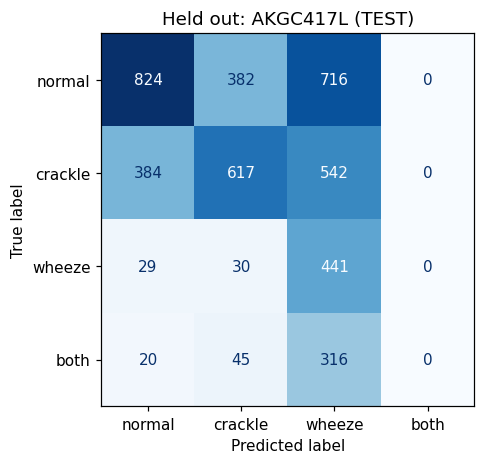


Held-out device: LittC2SE  (train=5001, val=1303, test=594)


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                       
------------------------+----------+---------------------------------------------------------------------------------------
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527]) vs model:torch.Size([4])          
classifier.dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527, 768]) vs model:torch.Size([4, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


[LittC2SE] Epoch 01 | val_ICBHI_score=69.20%
[LittC2SE] Epoch 02 | val_ICBHI_score=62.72%
[LittC2SE] Epoch 03 | val_ICBHI_score=69.21%
[LittC2SE] Epoch 04 | val_ICBHI_score=64.23%
[LittC2SE] Epoch 05 | val_ICBHI_score=65.23%
[LittC2SE] Epoch 06 | val_ICBHI_score=63.86%
[LittC2SE] Epoch 07 | val_ICBHI_score=66.99%
Early stopping at epoch 7
--- Held out: LittC2SE (TEST) ---
Sensitivity: 61.54%  Specificity: 89.05%  ICBHI Score: 75.29%
              precision    recall  f1-score   support

      normal       0.76      0.89      0.82       347
     crackle       0.32      0.35      0.33        77
      wheeze       0.70      0.54      0.61       126
        both       0.50      0.09      0.15        44

    accuracy                           0.69       594
   macro avg       0.57      0.47      0.48       594
weighted avg       0.67      0.69      0.66       594



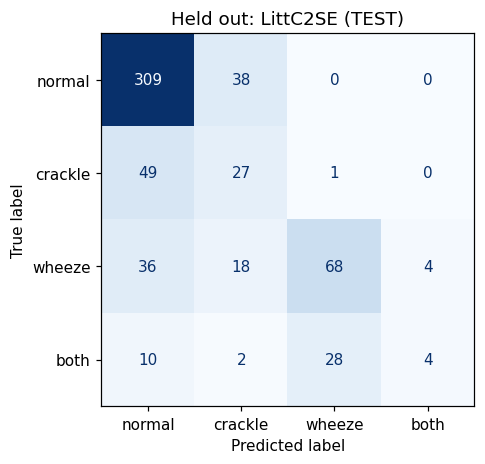


Held-out device: Litt3200  (train=5292, val=1104, test=502)


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                       
------------------------+----------+---------------------------------------------------------------------------------------
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527]) vs model:torch.Size([4])          
classifier.dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527, 768]) vs model:torch.Size([4, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


[Litt3200] Epoch 01 | val_ICBHI_score=71.41%
[Litt3200] Epoch 02 | val_ICBHI_score=73.00%
[Litt3200] Epoch 03 | val_ICBHI_score=65.79%
[Litt3200] Epoch 04 | val_ICBHI_score=71.09%
[Litt3200] Epoch 05 | val_ICBHI_score=71.56%
[Litt3200] Epoch 06 | val_ICBHI_score=71.00%
Early stopping at epoch 6
--- Held out: Litt3200 (TEST) ---
Sensitivity: 90.36%  Specificity: 12.20%  ICBHI Score: 51.28%
              precision    recall  f1-score   support

      normal       0.72      0.12      0.21       336
     crackle       0.67      0.07      0.12        29
      wheeze       0.25      0.96      0.39       112
        both       0.20      0.04      0.07        25

    accuracy                           0.30       502
   macro avg       0.46      0.30      0.20       502
weighted avg       0.59      0.30      0.24       502



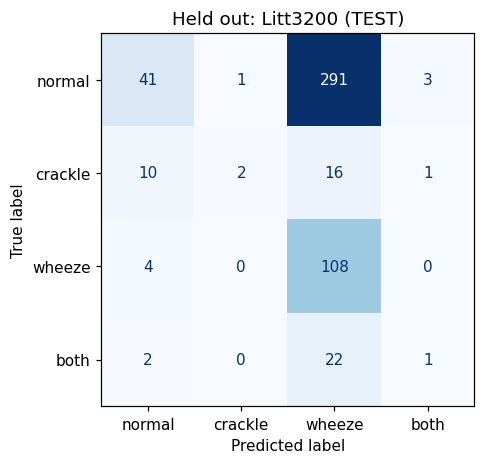


Held-out device: Meditron  (train=4245, val=1197, test=1456)


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                       
------------------------+----------+---------------------------------------------------------------------------------------
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527]) vs model:torch.Size([4])          
classifier.dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527, 768]) vs model:torch.Size([4, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


[Meditron] Epoch 01 | val_ICBHI_score=59.82%
[Meditron] Epoch 02 | val_ICBHI_score=61.32%
[Meditron] Epoch 03 | val_ICBHI_score=60.73%
[Meditron] Epoch 04 | val_ICBHI_score=63.62%
[Meditron] Epoch 05 | val_ICBHI_score=65.65%
[Meditron] Epoch 06 | val_ICBHI_score=61.32%
[Meditron] Epoch 07 | val_ICBHI_score=63.15%
[Meditron] Epoch 08 | val_ICBHI_score=62.71%
[Meditron] Epoch 09 | val_ICBHI_score=63.01%
Early stopping at epoch 9
--- Held out: Meditron (TEST) ---
Sensitivity: 74.22%  Specificity: 54.39%  ICBHI Score: 64.31%
              precision    recall  f1-score   support

      normal       0.84      0.54      0.66      1037
     crackle       0.27      0.71      0.39       215
      wheeze       0.51      0.44      0.47       148
        both       0.37      0.55      0.45        56

    accuracy                           0.56      1456
   macro avg       0.50      0.56      0.49      1456
weighted avg       0.70      0.56      0.59      1456



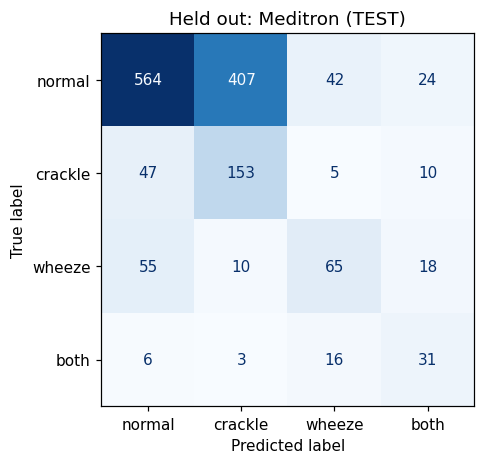

In [7]:
device_results = {}

for device in DEVICES_TO_RUN:
    train_fold, val_fold, test_fold = make_device_fold(full_df, device)
    if len(test_fold) < 20:
        print(f"WARNING: {device} has only {len(test_fold)} test cycles -- results will be noisy, interpret with caution.")
    device_results[device] = train_one_fold(device, train_fold, val_fold, test_fold)

## **8. Comparison: in-distribution vs. held-out**


                     model  icbhi_score_pct  gap_vs_in_distribution  \
0  Leave-one-out: AKGC417L            62.50                    4.72   
1  Leave-one-out: LittC2SE            75.29                   -8.07   
2  Leave-one-out: Litt3200            51.28                   15.94   
3  Leave-one-out: Meditron            64.31                    2.91   

                   notes  
0  train=2291, test=4346  
1   train=5001, test=594  
2   train=5292, test=502  
3  train=4245, test=1456  


/tmp/ipykernel_22/1798445049.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df["model"], rotation=20, ha="right")


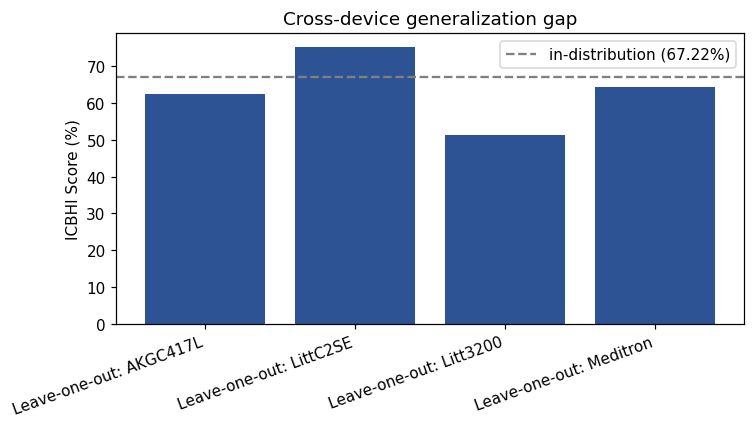

In [8]:
IN_DISTRIBUTION_SCORE = 67.22   # from Phase 3 (Focal + SpecAugment + Mixup, all devices mixed)

results_df = pd.DataFrame(results_log)
results_df["icbhi_score_pct"] = (results_df["icbhi_score"] * 100).round(2)
results_df["gap_vs_in_distribution"] = (IN_DISTRIBUTION_SCORE - results_df["icbhi_score_pct"]).round(2)

display_cols = ["model", "icbhi_score_pct", "gap_vs_in_distribution", "notes"]
print(results_df[display_cols])

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(results_df["model"], results_df["icbhi_score_pct"], color="#2E5395")
ax.axhline(IN_DISTRIBUTION_SCORE, linestyle="--", color="gray", label=f"in-distribution ({IN_DISTRIBUTION_SCORE}%)")
ax.set_xticklabels(results_df["model"], rotation=20, ha="right")
ax.set_ylabel("ICBHI Score (%)")
ax.set_title("Cross-device generalization gap")
ax.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/cross_device_gap.png", dpi=150)
plt.show()

## 9. Deliverable checklist

- Trained one model per held-out device (leave-one-device-out),
- Patient-level leakage check within each fold's training pool
- Every fold evaluated on its held-out device's test cycles exactly once


**Next:** `04b_noise_robustness_sweep.ipynb`.